In [1]:
import torch
import pandas as pd
from matplotlib import pyplot as plt
import gymnasium as gym
import joblib
import numpy as np
import os

In [8]:
import torch
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

# Define your neural network architecture
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Set hyperparameters
input_size = 10
hidden_size = 20
output_size = 1
learning_rate = 0.001
num_epochs = 100

# Create an instance of the neural network
model = NeuralNetwork()

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Prepare your training data
train_dataset = YourDataset()  # Replace YourDataset with your own dataset class
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop
for epoch in range(num_epochs):
    for batch_idx, (inputs, targets) in enumerate(train_dataloader):
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the loss after each epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}")

# Save the trained model
torch.save(model.state_dict(), 'trained_model.pth')

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Equipo 3\AppData\Local\Temp\ipykernel_4268\4020515246.py:2: SyntaxWarning: invalid escape sequence '\e'
  policy = torch.load('training_results\ems\TD3_20240527_230946\policy_ep_400.pt')


AttributeError: 'ActorNN' object has no attribute 'device'

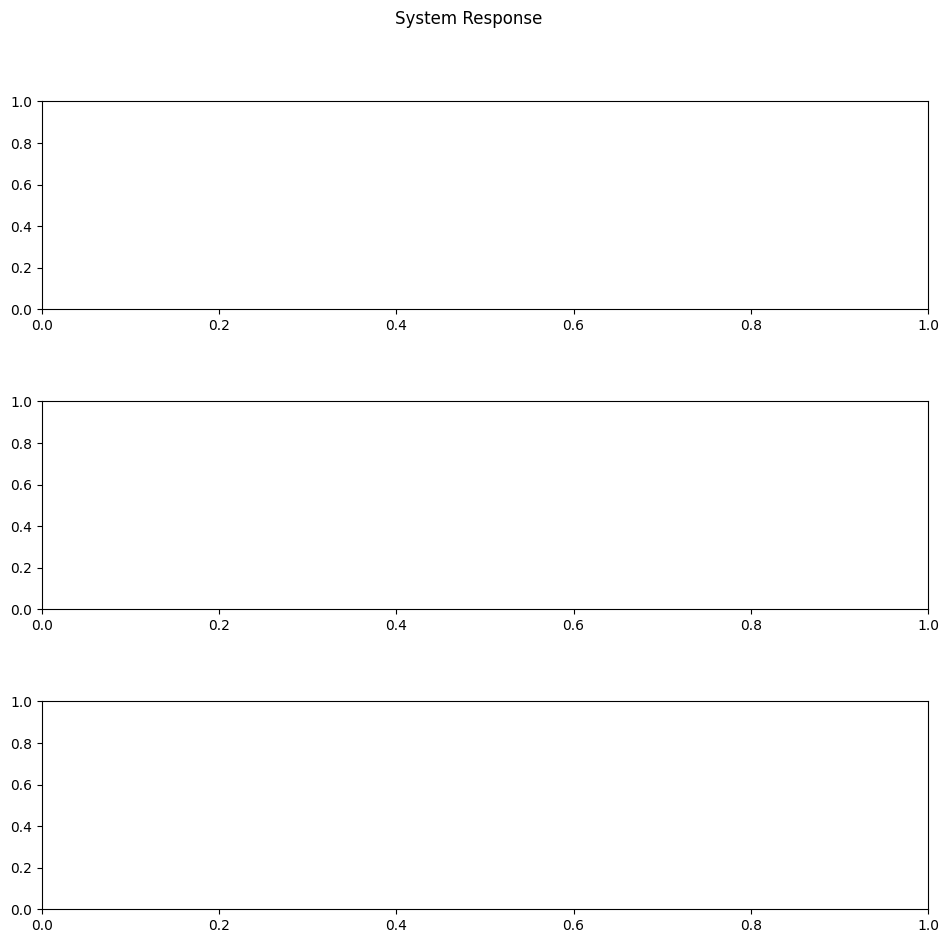

In [4]:
quad = Quad_env()
policy = torch.load('training_results\ems\TD3_20240527_230946\policy_ep_400.pt')
policy.eval()

quad.show_sample(policy)

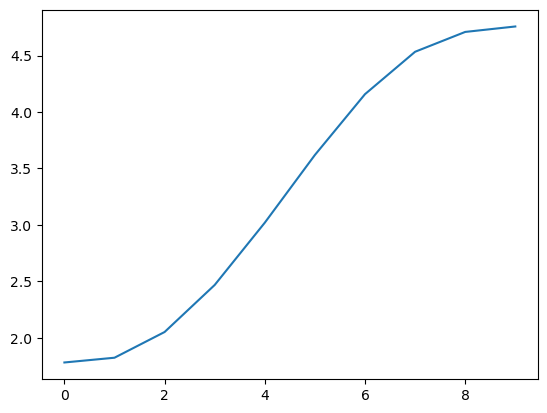

In [26]:
state, _ = quad.reset()
policy.eval()
states = []
for i in range(100):
    action = policy(state)
    state, _, _, _, _= quad.step(action.cpu().detach().numpy())
    states.append(state[1])
plt.plot(states[0:10])

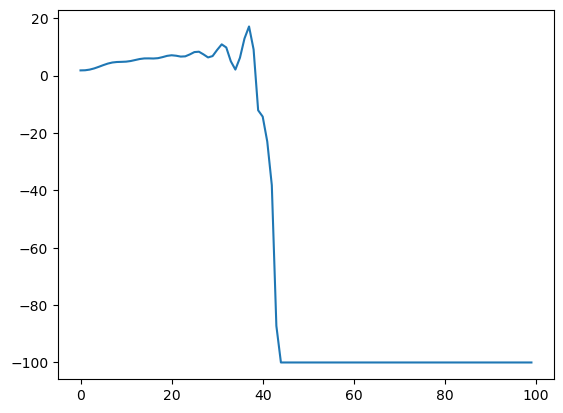

In [27]:
plt.plot(states[0:])

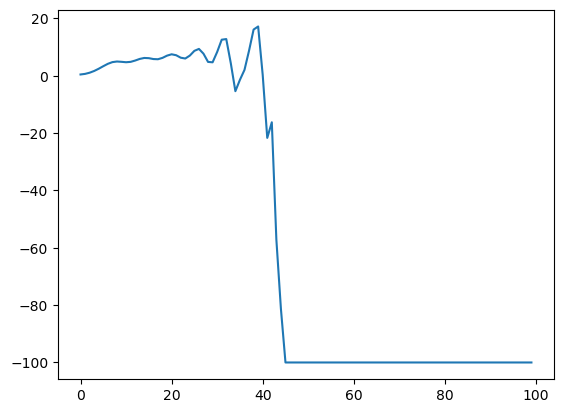

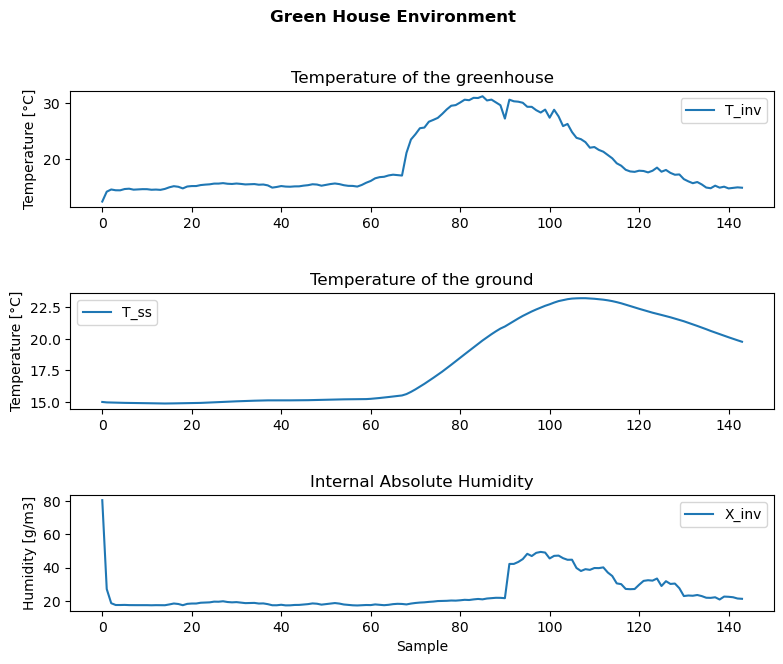

In [3]:
import torch
import pandas as pd
from matplotlib import pyplot as plt
# Enable TeX rendering
import joblib
import numpy as np
from environments.GH_env import*
from environments.EMS_env import EMS_env, EMS_env2
from environments.Quad_env import Quad_env
import os

gh_env = GH_env()

# plot the sample trajectory
gh_env.show_sample(policy=lambda x, t: np.array([0.0]) if t < 90 else np.array([0.99]))
gh_env.fig.set_size_inches(8, 7)
gh_env.fig.savefig('figures/greenhouse_simu.png', dpi = 300)
df = gh_env.variables

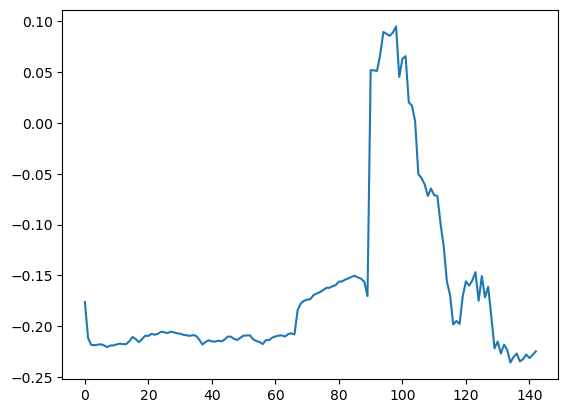

In [2]:
plt.plot(np.cumsum(np.array(df["x_evap"])-np.array(df["x_vent"])-np.array(df["x_c"])))
#plt.plot(np.array(df["x_vent"]))
#plt.plot(np.array(df["x_c"]))

#plt.plot(df["X_inv"])

In [1]:
pip install stable-baselines3[extra]

  Obtaining dependency information for protobuf<3.20,>=3.9.2 from https://files.pythonhosted.org/packages/9b/6e/ffecb6488629407ac44ec956990c616eb56fd0069a81a9e28feeed8a2ca2/protobuf-3.19.6-cp39-cp39-win_amd64.whl.metadata
Using cached protobuf-3.19.6-cp39-cp39-win_amd64.whl (895 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnx 1.13.1 requires protobuf<4,>=3.20.2, but you have protobuf 3.19.6 which is incompatible.


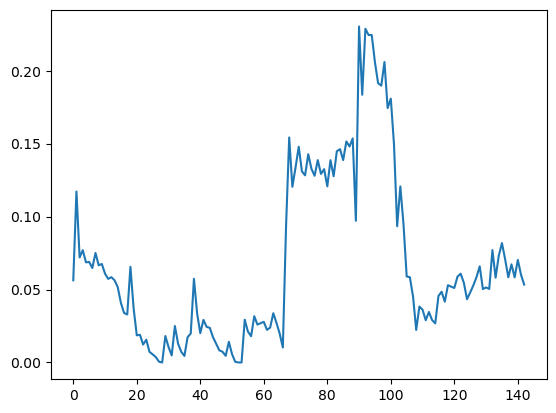

In [8]:
plt.plot(df["ET_0"])

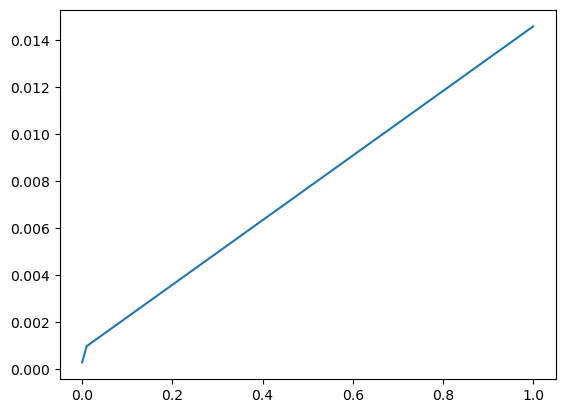

In [6]:
def Ren_air(w_speed, W):
    """Calculates the air renovation rate [m3/s]"""
    w_speed_w = w_speed*np.log(67.8*z_w - 5.42)/np.log(67.8*z-5.42) # velocidad del viento a la altura de la ventana [m/s]
    G = w_speed_w*A_w*W # [m3/s]
    return G/V_inv + R_inf if W > 0 else R_inf/3

a = lambda x: Ren_air(3, x)
ww = np.linspace(0, 1, 100)

plt.plot(ww, [a(x) for x in ww])

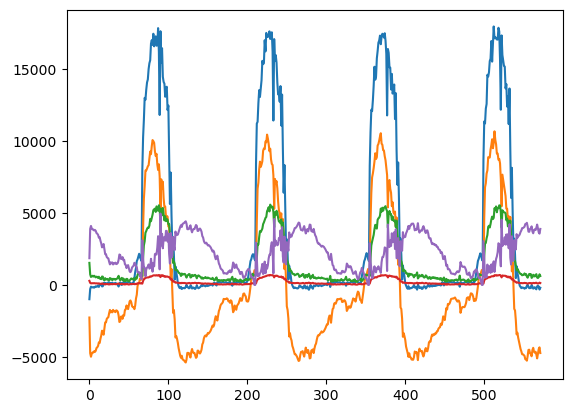

In [3]:
#plt.plot(np.array(df['Q_rad']) - np.array(df['Q_g']) - np.array(df['Q_cc']) - np.array(df['Q_ren']) - np.array(df['Q_evp'])) #- np.array(df['Q_h']))
plt.plot(df['Q_rad'])
plt.plot(df['Q_g'])
plt.plot(df['Q_cc'])
plt.plot(df['Q_ren'])
plt.plot(df['Q_evp'])

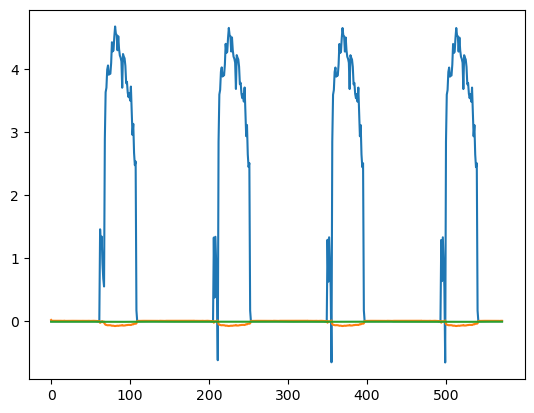

In [3]:
# plot the humidities 

plt.plot(A_c/V_inv*np.array(df['x_evap']))
plt.plot(df['x_c'])
plt.plot(df['x_vent'])

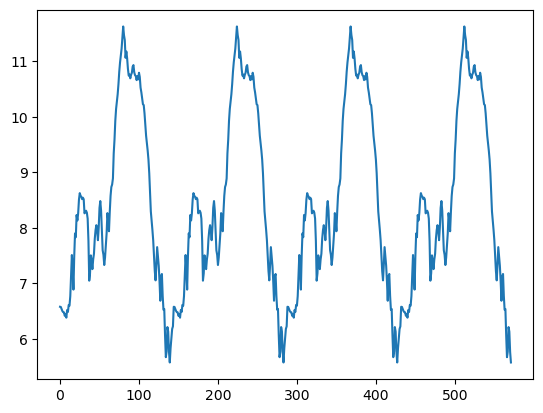

In [4]:
plt.plot(df["T_ext"])

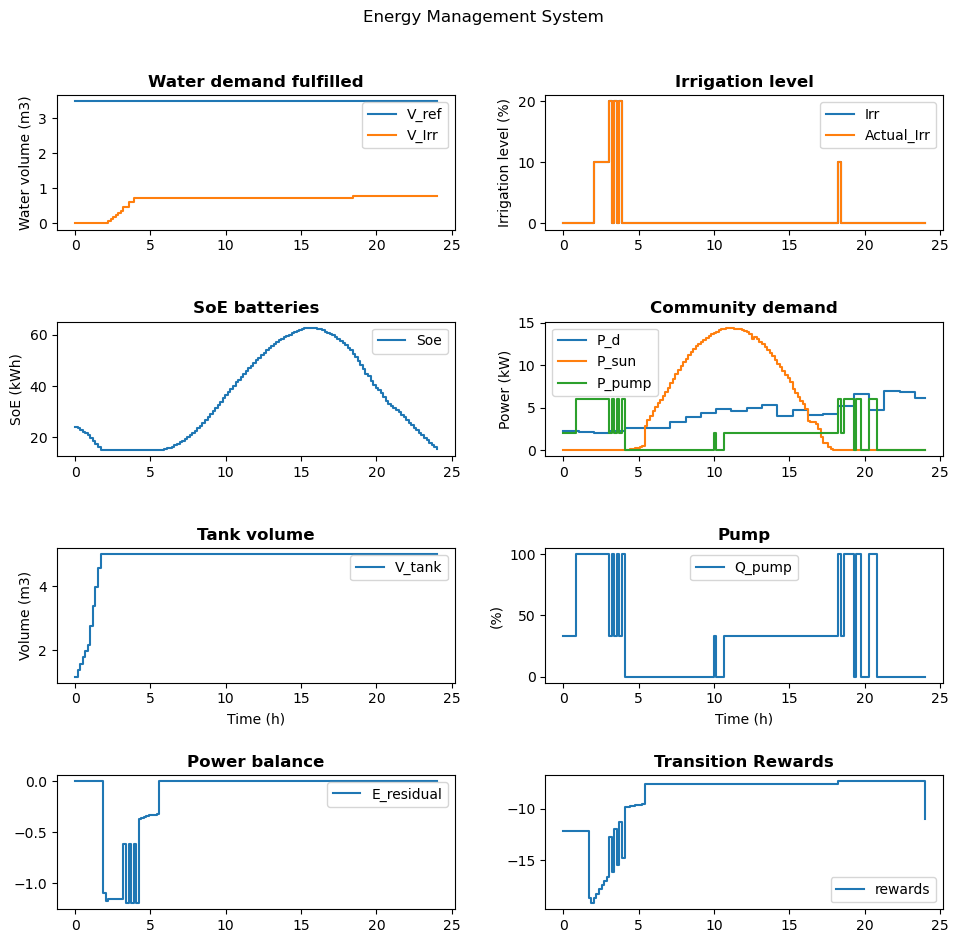

In [5]:
from environments.EMS_env import EMS_env
ems_env = EMS_env()
policy = torch.load('training_results\ems\DQN_20240520_130432\policy_ep_200.pt')
#policy = policies[5]
ems_env.show_sample(policy)

C:\Users\wenap\AppData\Local\Temp\ipykernel_12144\2297357141.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/freq[0:L//8], np.abs(np.fft.fft(T_inv)[0:L//8]))
C:\Users\wenap\AppData\Local\Temp\ipykernel_12144\2297357141.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/freq[0:L//8], np.abs(np.fft.fft(T_ext)[0:L//8]))


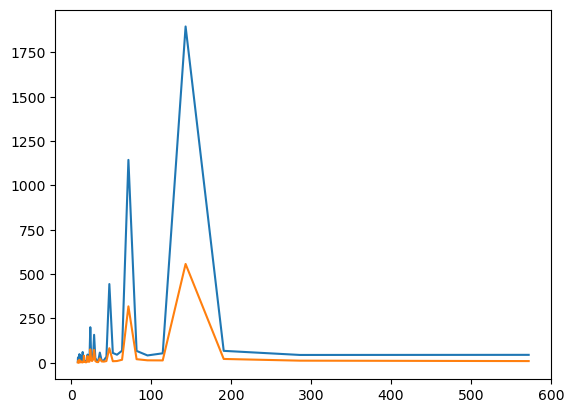

In [8]:
T_inv = np.array(df["T_inv"])
T_ext = np.array(df["T_ext"])

freq = np.fft.fftfreq(len(T_inv), 1)
L = len(T_inv)

plt.plot(1/freq[0:L//8], np.abs(np.fft.fft(T_inv)[0:L//8]))
plt.plot(1/freq[0:L//8], np.abs(np.fft.fft(T_ext)[0:L//8]))

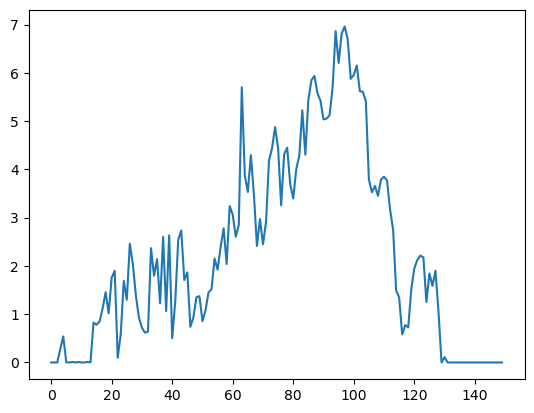

In [15]:
plt.plot(gh_env.w_speed_data)

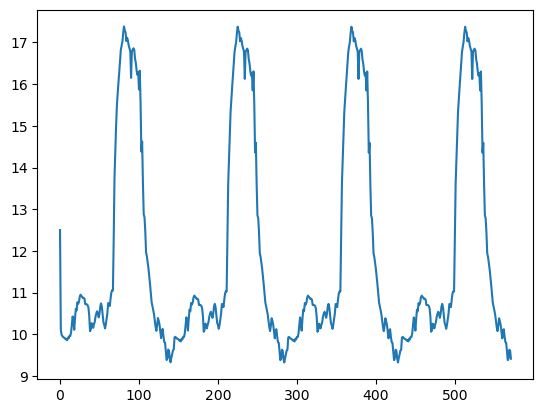

In [7]:
plt.plot(np.array(df['X_inv']))

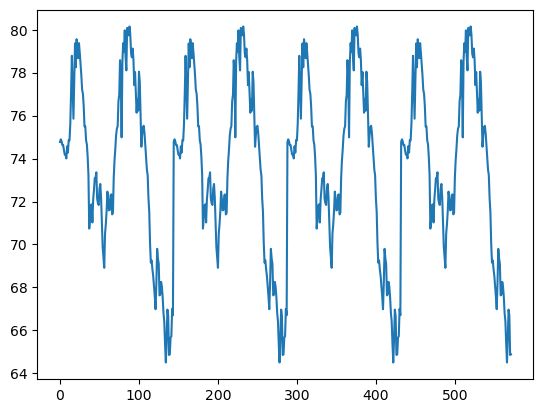

In [5]:
plt.plot(df["X_ext"])

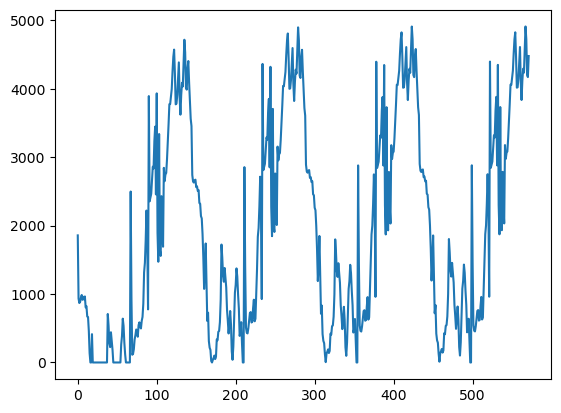

In [5]:
plt.plot(df['Q_evp'])

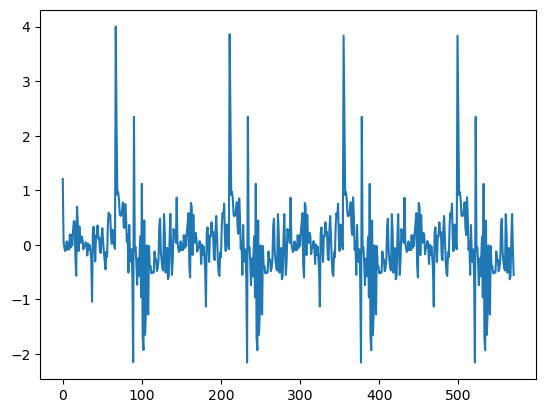

In [6]:
plt.plot(np.diff(np.array(df['T_inv'])))

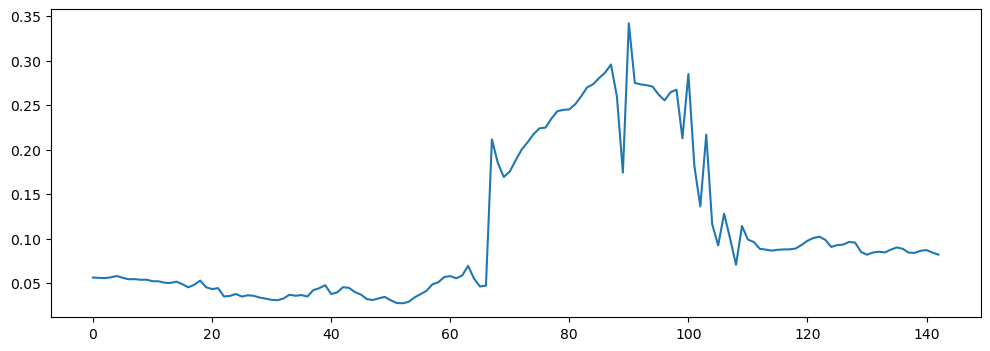

In [18]:
plt.plot(df["ET_0"])
fig = plt.gcf()
fig.set_size_inches(12, 4)
""

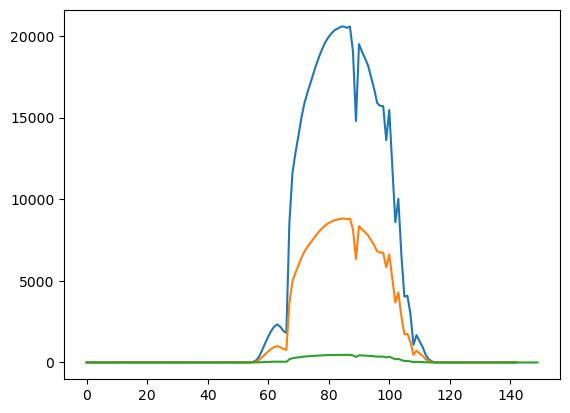

In [12]:
plt.plot(np.array(df["R_n"]))
plt.plot(np.array(df["R_n_c"])*A_c)
plt.plot(gh_env.I_data)

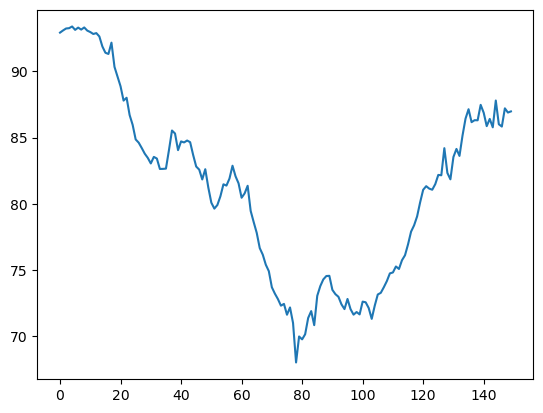

In [7]:
plt.plot(np.array(gh_env.RH_ext_data))

In [2]:
# list of policies  
path = 'training_results\ems\DQN_20240520_130432'
path2 = 'training_results\ems\DQN_20240520_222049'

folder = os.listdir(path)
folder2 = os.listdir(path2)

policies = [torch.load(path + r"\\" + policy) for policy in folder if policy.endswith('.pt')]
policies2 = [torch.load(path2 + r"\\" + policy) for policy in folder2 if policy.endswith('.pt')]

-0.03142506767335399 -352.68210972910623 0.11587924383148261
-0.08206304672314171 -678.7872050578089 0.39079233029072874
-0.1140965329408617 -791.822633330524 1.972962062521583
-0.1608750759287215 -5179.803563979601 -8.799485313423501
-0.08555393653313766 -535.1618123638304 1.1254680003248294
-0.3716252851863349 -916.0015508585424 1.783261012844163
-0.5755536096081264 -1158.9812640095656 1.956400718705103
-0.4646831124222705 -920.6299894313328 1.6609539259644095
-0.03142852996355565 -647.6079091291635 1.8365669206264466
-0.043239599982058924 -403.5035616461685 1.3849741508336613
-0.015509885541527994 -558.8264546743947 1.6960401702641872
-0.019693236226549445 -612.009174827619 1.8840469170511958
-0.01893282519392987 -481.18101807578 1.529363953078999
-0.03070816430262144 -619.1555579461296 1.688507169920202
-0.034785987990644085 -675.0920481316 1.846824718294829
-0.008278491089741801 -399.7638068779977 1.3944481724854243
-0.01767909800925906 -657.1215113820135 1.8423592859717346
-0.051

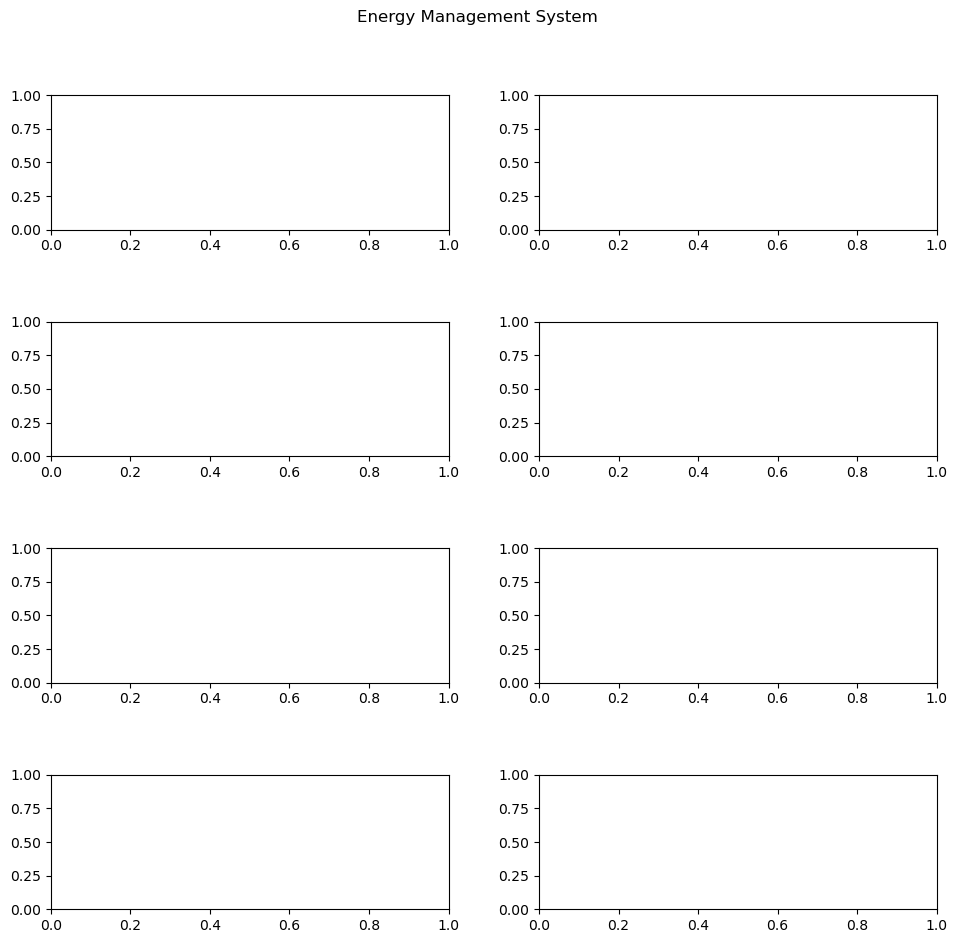

In [3]:
# numero de rebalses  
ep_per_policy = 25
env = EMS_env()

deficit_ratio = []
final_energy_balance = []
overflow_occurrence = []
precision = []


for i in range(len(policies)):
    total_steps = 0
    def_rat = 0
    num_pen = 0
    
    errors = np.zeros(ep_per_policy)
    rewards = np.zeros(ep_per_policy)
    for j in range(ep_per_policy):
        total_steps += 143
        states, actions, rews = env.sample_trajectory(policies[i], None, 143)
        def_rat += np.sum(np.array([val for val in states[1:,-1] if val < 0]))
        num_pen += np.sum(np.logical_and(actions[:,0]>0, states[:-1,3]>=5))
        errors[j] = states[-1,0] - states[-1,1]
        rewards[j] = np.sum(rews)

    print(def_rat/total_steps, np.mean(rewards), np.mean(errors))
    deficit_ratio.append(def_rat/total_steps)
    overflow_occurrence.append(num_pen/total_steps)
    precision.append(np.mean(errors))

IndexError: index 1 is out of bounds for axis 0 with size 1

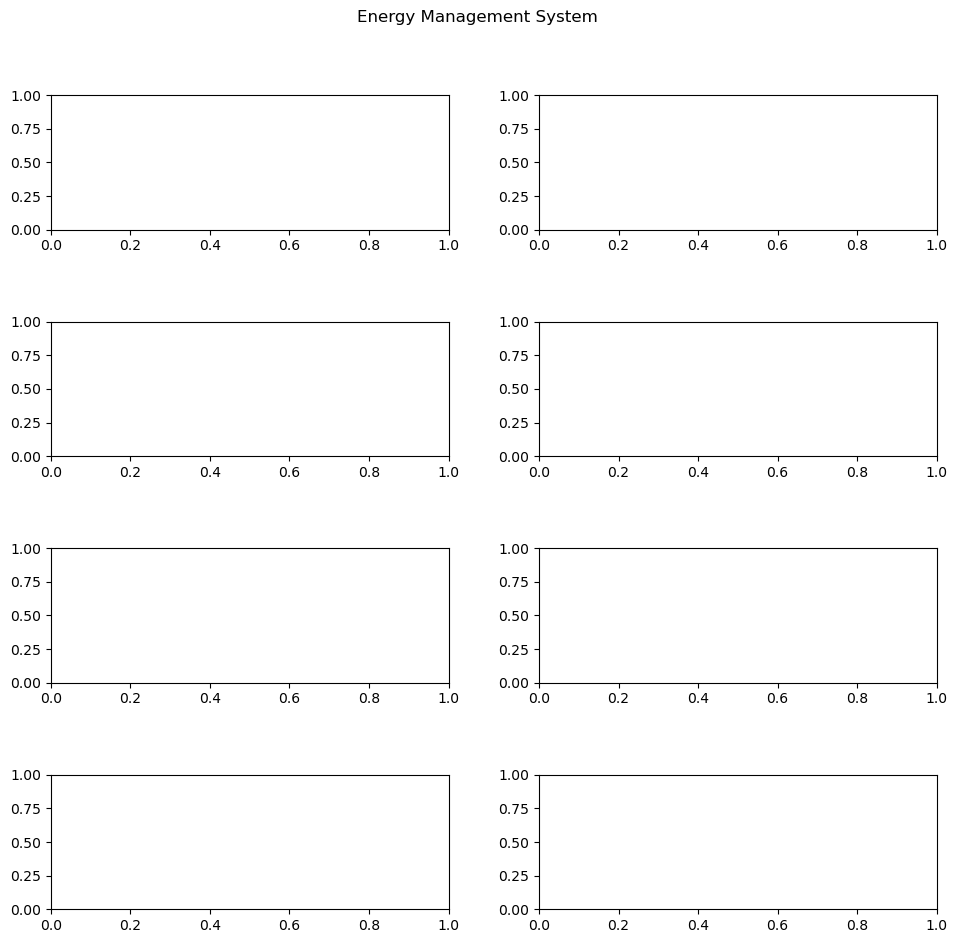

In [4]:
# numero de rebalses  
ep_per_policy = 25
env2 = EMS_env2()

deficit_ratio2 = []
final_energy_balance2 = []
overflow_occurrence2 = []
precision2 = []


for i in range(len(policies)):
    total_steps = 0
    def_rat = 0
    num_pen = 0
    
    errors = np.zeros(ep_per_policy)
    rewards = np.zeros(ep_per_policy)
    for j in range(ep_per_policy):
        total_steps += 143
        states, actions, rews = env2.sample_trajectory(policies2[i], None, 143)
        def_rat += np.sum(np.array([val for val in states[1:,-1] if val < 0]))
        num_pen += np.sum(np.logical_and(actions[:,0]>0, states[:-1,3]>=5))
        errors[j] = states[-1,0] - states[-1,1]
        rewards[j] = np.sum(rews)

    print(def_rat/total_steps, np.mean(rewards), np.mean(errors))
    deficit_ratio2.append(def_rat/total_steps)
    overflow_occurrence2.append(num_pen/total_steps)
    precision2.append(np.mean(errors))

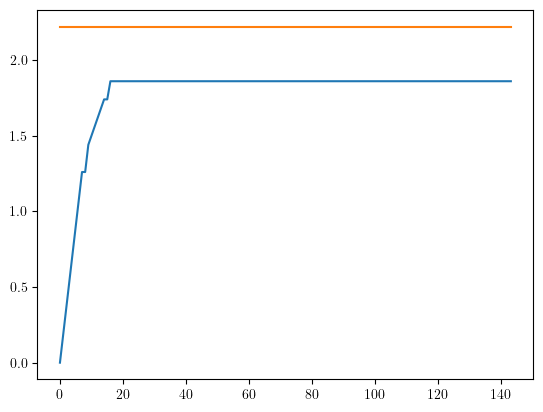

In [31]:
plt.plot(states[:,1])
plt.plot(states[:,0])

In [33]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

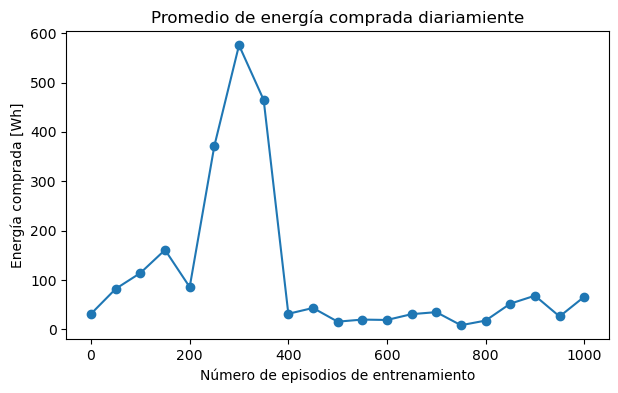

In [5]:
eps = np.linspace(0, 50*20 , len(deficit_ratio))
plt.plot(eps, -1000*np.array(deficit_ratio), marker='o', label='agent based')
#plt.plot(eps, -1000*np.array(deficit_ratio2), marker='o', label='agent-rule based')
plt.title(r"Percentage of time in deficit")
plt.ylabel(r"Energía comprada [Wh]")
plt.xlabel(r"Número de episodios de entrenamiento")
plt.title(r"Promedio de energía comprada diariamiente")
#plt.legend()

fig = plt.gcf()
fig.set_size_inches(7, 4)
fig.savefig("deficit.png", dpi=300) 


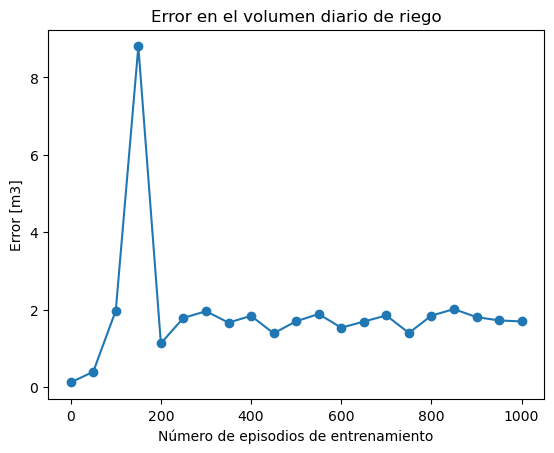

In [8]:
plt.plot(eps, np.abs(np.array(precision)), marker='o', label='agent_based')
#plt.plot(eps, np.abs(np.array(precision2)), marker='o', label='agent-rule_based')
plt.xlabel(r"Número de episodios de entrenamiento")
plt.ylabel(r"Error [m3]")
plt.title(r"Error en el volumen diario de riego")
#plt.legend()
plt.savefig("figures/error.png", dpi=300)

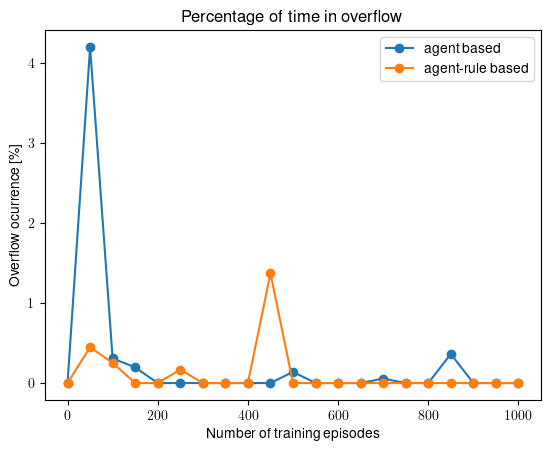

In [15]:
plt.plot(eps, 100*np.array(overflow_occurrence), marker='o', label='agent based')
plt.plot(eps, 100*np.array(overflow_occurrence2), marker='o', label='agent-rule based')
plt.title(r"Percentage of time in overflow", fontweight='heavy')
plt.ylabel(r"Overflow ocurrence [\%]")
plt.xlabel(r"Number of training episodes")
plt.legend()
plt.savefig("figures/overflow.png", dpi=300)

In [41]:
#create a dataframe with the collected stats 



eps = np.array([i*50 for i in range(0, len(deficit_ratio))])

data = {'Deficit ratio': deficit_ratio, 
        'Overflow occurrence': overflow_occurrence, 
        'Precision': precision, 
        'Episodes': eps}
df = pd.DataFrame(data)

In [ ]:
env.fig.savefig("sample.png", dpi=300)

: 

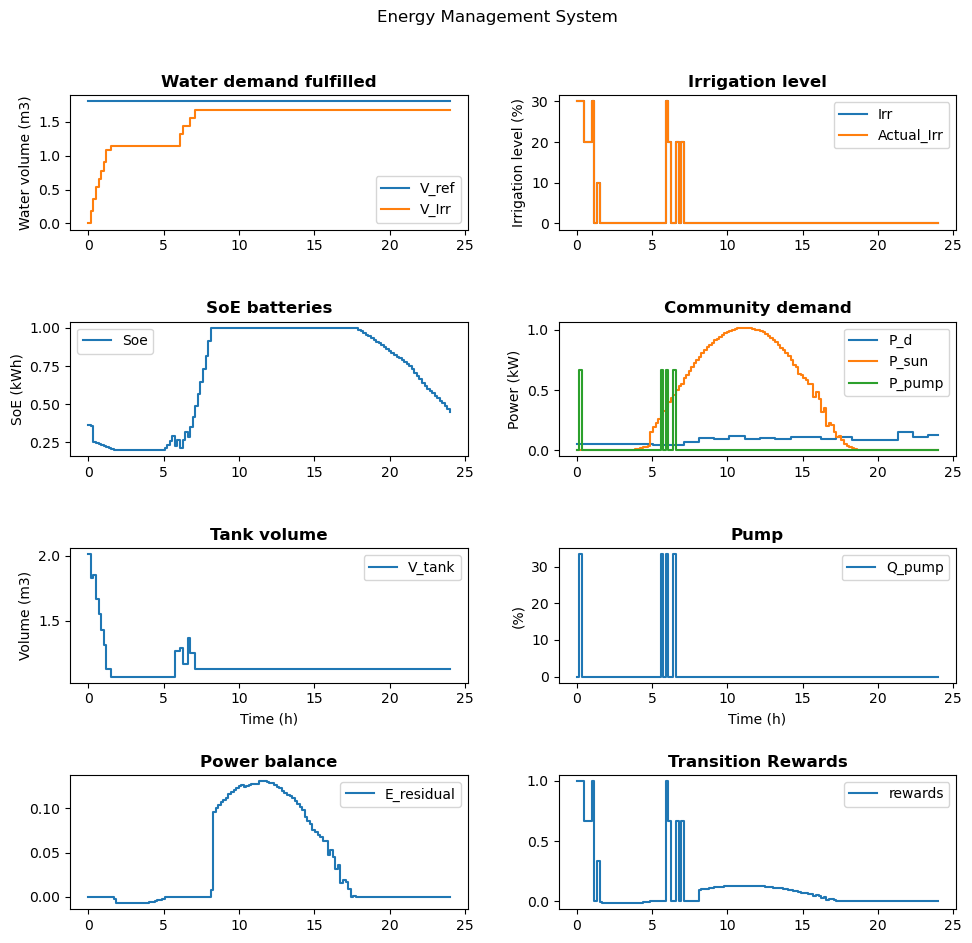

In [12]:
policy = policies[11]

env = EMS_env()

env.show_sample(policy)
plt.savefig("figures/sample.png", dpi=300)


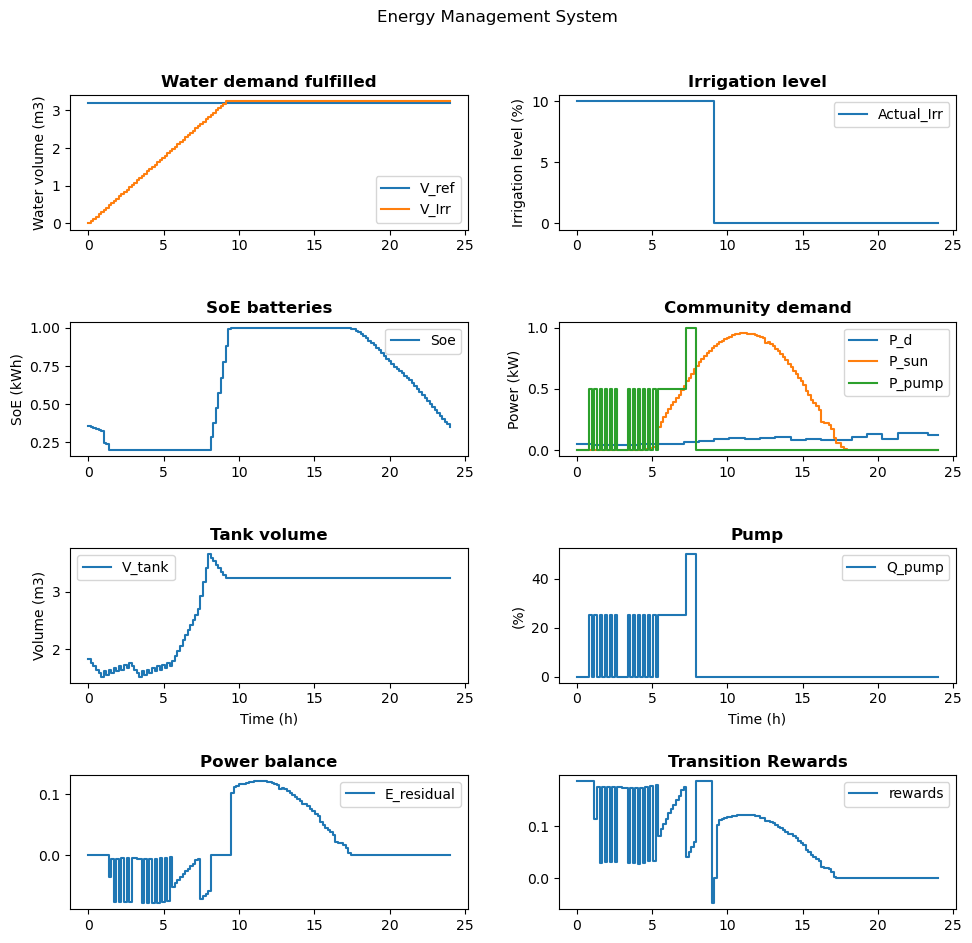

In [13]:
policy2 = policies2[8]

env2 = EMS_env2()

env2.show_sample(policy2)
plt.savefig("figures/sample2.png", dpi=300)

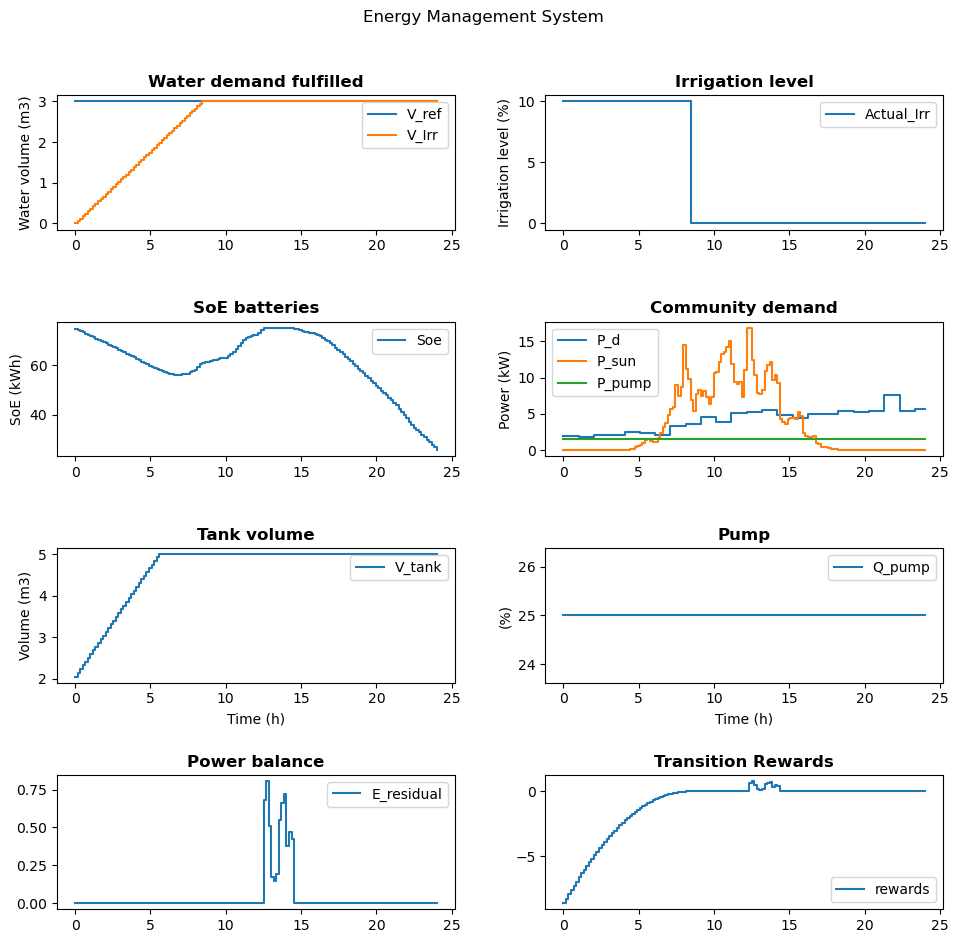

In [15]:
policy2 = policies2[8]

env2 = EMS_env2()

env2.show_sample(policy2)
plt.savefig("figures/sample2.png", dpi=300)

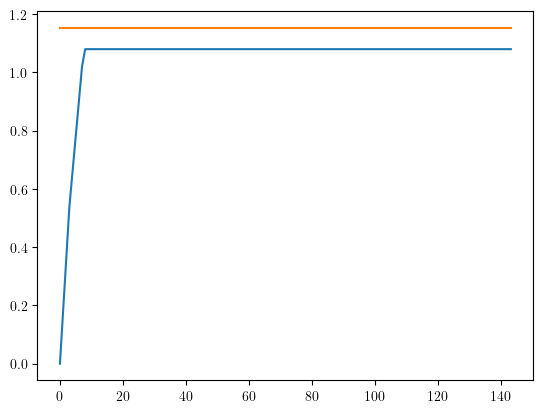

In [18]:
plt.plot(states[:,1])
plt.plot(states[:,0])

In [14]:
gh_env = GH_env()

# plot the sample trajectory
gh_env.show_sample(None)


TypeError: Can't instantiate abstract class GH_env with abstract method sample_trajectory